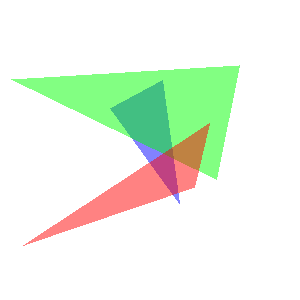

In [1]:
from PIL import Image, ImageDraw

polygons = [
    {'vertices': [(179, 203), (162, 80), (110, 108)],
     'RGBA': (0, 0, 255, 125)},
    {'vertices': [(239, 65), (216, 179), (11, 79)], 'RGBA': (0, 255, 0, 125)},
    {'vertices': [(209, 123), (23, 245), (194, 187)], 'RGBA': (255, 0, 0, 125)}
]


def draw(polygons, size):
    """ Функция для рисования многоугольников """

    img = Image.new('RGB', (size[0], size[1]), (255, 255, 255))
    drw = ImageDraw.Draw(img, 'RGBA')

    for pol in polygons:
        drw.polygon(pol['vertices'], pol['RGBA'])

    return (img.convert("RGB"))


draw(polygons, size=(300, 300))

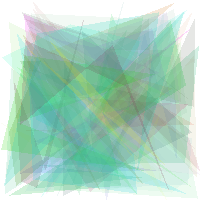

In [2]:
import numpy as np


def random_triangles(N, size, vertices=3, colour="random", alpha="random"):
    """ Функция создания популяции рандомных треугольников """

    collection = []

    for i in range(N):
        coords = [(np.random.randint(0, size[0]), np.random.randint(0, size[1]))
                  for i in range(vertices)]

        if alpha == "random":
            a = np.random.randint(0, 50)
        else:
            a = alpha

        if colour == "white":
            rgba = (255, 255, 255, a)
        elif colour == "black":
            rgba = (0, 0, 0, a)
        elif colour == "random":
            rgba = (np.random.randint(0, 256), np.random.randint(
                0, 256), np.random.randint(0, 256), a)

        triangle = {"vertices": coords, "RGBA": rgba}
        collection.append(triangle)

    return (collection)


collection = random_triangles(N=50, size=(
    200, 200), vertices=5, colour="random", alpha="random")
img = draw(collection, size=(200, 200))
img

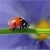

In [4]:
image_path = "images\\bug.png"
target = Image.open(image_path).convert("RGB")

# Уменьшить до конкретного размера, например 200x200 пикселей
new_size = (50, 50)
target = target.resize(new_size)

target

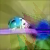

In [5]:
from PIL import ImageChops

ImageChops.difference(img, target)

In [6]:
def pixel_difference(candidate, target):
    """ Функция для попиксельного вычисления отличий между картинками"""
    diff = ImageChops.difference(candidate, target)
    totdiff = np.array(diff.getdata()).sum()
    return (totdiff)


diff = pixel_difference(img, target)
diff

np.int64(905994)

In [7]:
def max_pixel_difference(target):
    """ Функция вычисления максимально возможной разницы между изображениями"""
    white = Image.new('RGB', target.size, (255, 255, 255))
    diff = ImageChops.difference(white, target)
    maxdiff = np.array(diff.getdata()).sum()
    return (maxdiff)


maxdiff = max_pixel_difference(target)
fitness = (1 - diff / maxdiff) * 100
print("Fitness = " + str(np.round(fitness, 4)) + "%")

Fitness = 15.2217%


In [8]:
import copy
import matplotlib.pyplot as plt


def mutation(original, size):
    """ Функция мутации """
    mutant = copy.deepcopy(original)
    polidx = np.random.randint(len(mutant))

    # Случайно выбираем, что именно мутировать: вершины, цвет или прозрачность
    what = np.random.choice(["vertex", "color", "alpha"])

    if what == "vertex":
        vidx = np.random.randint(len(mutant[polidx]["vertices"]))
        new_v = (
            np.random.randint(-10, size[0] + 10),
            np.random.randint(-10, size[1] + 10)
        )
        mutant[polidx]["vertices"][vidx] = new_v

    elif what == "color":
        r, g, b, a = mutant[polidx]["RGBA"]
        mutant[polidx]["RGBA"] = (
            np.random.randint(0, 256),
            np.random.randint(0, 256),
            np.random.randint(0, 256),
            a
        )

    elif what == "alpha":
        r, g, b, a = mutant[polidx]["RGBA"]
        mutant[polidx]["RGBA"] = (r, g, b, np.random.randint(0, 256))

    return mutant


In [9]:
def pop_fitness(pop, target):
    """
    Вычисляет приспособленность каждой популяции
    """

    size = target.size
    maxdiff = max_pixel_difference(target)

    fitvec = []

    for org in pop:
        img = draw(org[0], size)
        diff = pixel_difference(img, target)
        fitness = (1 - diff / maxdiff) * 100
        fitvec.append(fitness)

    return (fitvec)


def individ_fitness(individ, target):
    """
    Вычисление приспособленности индивида
    """

    size = target.size
    maxdiff = max_pixel_difference(target)

    img = draw(individ, size)
    diff = pixel_difference(img, target)
    fitness = (1 - diff / maxdiff) * 100

    return (fitness)

In [10]:
def random_polygons(N, size, num_verts=3, colour="random", alpha="random"):
    """ Создание рандомных многоугольников """

    collection = []

    for i in range(N):
        max_tri_size = min(size[0], size[1]) // 8
        cx = np.random.randint(0, size[0])
        cy = np.random.randint(0, size[1])
        coords = [(cx + np.random.randint(-max_tri_size, max_tri_size),
                   cy + np.random.randint(-max_tri_size, max_tri_size)) for i in range(num_verts)]

        if alpha == "random":
            a = np.random.randint(0, 50)
        else:
            a = alpha

        if colour == "white":
            rgba = (255, 255, 255, a)
        elif colour == "black":
            rgba = (0, 0, 0, a)
        elif colour == "random":
            rgba = (np.random.randint(0, 256), np.random.randint(
                0, 256), np.random.randint(0, 256), a)

        triangle = {"vertices": coords, "RGBA": rgba}
        collection.append(triangle)

    return (collection)


def create_pop(Npop, N, size, num_verts=3, colour_init="black", alpha_init=100):
    """
    Создание популяции рандомных особей
    Каждая особь имеет N рандомно созданных многоугольников
    """

    pop = []
    for i in range(Npop):
        individ = random_polygons(
            N, size, num_verts=num_verts, colour=colour_init, alpha=alpha_init)
        fitness = individ_fitness(individ, target)
        pop.append((individ, fitness))

    pop = sorted(pop, key=lambda x: (x[1]), reverse=True)
    return pop


pop = create_pop(Npop=20, N=100, size=(200, 200), num_verts=2,
                 colour_init="random", alpha_init="random")

In [11]:
def crossover(parent1, parent2, size, pmut=0.1):
    """
    Функция кроссинговера (одноточечный).
    Делит оба родителя в случайной точке и создаёт потомка из двух частей.
    С вероятностью pmut применяет мутацию к потомку.
    """
    # Точка разреза (не крайние позиции)
    point = np.random.randint(1, len(parent1))

    child = parent1[:point] + parent2[point:]

    # Мутация с заданной вероятностью
    if np.random.rand() < pmut:
        child = mutation(child, size)

    return child


In [12]:
def new_generation(pop, fitness, size, pmut=0.1, num_of_olds=0.5):
    """Функция создания нового (следующего) поколения.

    Стратегия:
      - Элитарный отбор: лучшие num_of_olds особей переходят без изменений.
      - Остальные создаются кроссинговером двух родителей, выбранных
        методом рулетки (пропорционально приспособленности).
    """
    n = len(pop)
    n_old = max(1, int(n * num_of_olds))

    new_pop = []

    for i in range(n_old):
        new_pop.append(pop[i])

    fitvec = np.array([ind[1] for ind in pop], dtype=float)
    fitvec -= fitvec.min() - 1e-6
    probs = fitvec / fitvec.sum()

    while len(new_pop) < n:
        idx1, idx2 = np.random.choice(len(pop), size=2, replace=False, p=probs)
        parent1 = pop[idx1][0]
        parent2 = pop[idx2][0]

        child = crossover(parent1, parent2, size, pmut=pmut)
        child_fitness = individ_fitness(child, target)
        new_pop.append((child, child_fitness))

    new_pop = sorted(new_pop, key=lambda x: x[1], reverse=True)
    return new_pop


In [13]:
import pandas as pd
import time
import os


def mean(list):
    sum = 0
    for elem in list:
        sum += elem[1]
    return sum/len(list)


def genetic_triangle_painting(target, Npop, Ntri=100, num_verts=3, maxgen=10, every=20, pmut=0.1, num_of_olds=0.1, colour_init="random", alpha_init="random", logs=True, outdir="output_images"):

    size = target.size

    os.makedirs(outdir, exist_ok=True)

    pop_time = time.time()
    pop = create_pop(Npop=Npop, N=Ntri, size=size, num_verts=num_verts,
                     colour_init=colour_init, alpha_init=alpha_init)
    fitness = pop_fitness(pop, target)
    pop_time = time.time() - pop_time

    info = []
    maxfit = 0

    for i in range(maxgen+1):
        maxfit = pop[0][1]
        if i % every == 0:
            avgfit = mean(pop)

            best = pop[0][0]
            best_img = draw(best, size=size)
            outpath = outdir + "/generation_" + str(i) + ".png"
            best_img.save(outpath)
            info.append([i, maxfit, avgfit, pop_time, outpath])
            if logs == True:
                print("Generation: " + str(i) + "    Max. Fitness: " + str(np.round(maxfit, 2)) +
                      "%    Avg. Fitness: " + str(np.round(avgfit, 2)) + "%" + "   Time: "+str(pop_time))

        pop_time = time.time()
        newpop = new_generation(pop, fitness, size=size,
                                pmut=pmut, num_of_olds=num_of_olds)
        fitness = pop_fitness(newpop, target)
        pop_time = time.time() - pop_time
        pop = newpop

    dfout = pd.DataFrame(
        info, columns=["generation", "max_fitness", "avg_fitness", "time", "outpath"])
    return (dfout)

In [14]:
df = genetic_triangle_painting(
    target,
    Npop=20,
    Ntri=100,
    num_verts=3,
    maxgen=4000,
    every=200,
    pmut=0.1,
    num_of_olds=0.2,
    colour_init="random",
    alpha_init="random",
    logs=True,
    outdir="output_images"
)

df

Generation: 0    Max. Fitness: 6.6%    Avg. Fitness: 5.45%   Time: 0.10554671287536621
Generation: 200    Max. Fitness: 52.03%    Avg. Fitness: 52.02%   Time: 0.041999101638793945
Generation: 400    Max. Fitness: 70.52%    Avg. Fitness: 70.49%   Time: 0.0469973087310791
Generation: 600    Max. Fitness: 75.34%    Avg. Fitness: 75.34%   Time: 0.06499814987182617
Generation: 800    Max. Fitness: 78.38%    Avg. Fitness: 78.35%   Time: 0.046639204025268555
Generation: 1000    Max. Fitness: 80.74%    Avg. Fitness: 80.73%   Time: 0.051000118255615234
Generation: 1200    Max. Fitness: 81.97%    Avg. Fitness: 81.96%   Time: 0.04561948776245117
Generation: 1400    Max. Fitness: 83.23%    Avg. Fitness: 83.23%   Time: 0.04153561592102051
Generation: 1600    Max. Fitness: 83.87%    Avg. Fitness: 83.87%   Time: 0.045000314712524414
Generation: 1800    Max. Fitness: 84.98%    Avg. Fitness: 84.97%   Time: 0.04729628562927246
Generation: 2000    Max. Fitness: 85.91%    Avg. Fitness: 85.88%   Time: 0.04

,generation,max_fitness,avg_fitness,time,outpath
0,0,6.598058,5.446263,0.105547,output_images/generation_0.png
1,200,52.033522,52.021835,0.041999,output_images/generation_200.png
2,400,70.519144,70.492714,0.046997,output_images/generation_400.png
3,600,75.341431,75.341431,0.064998,output_images/generation_600.png
4,800,78.376064,78.346995,0.046639,output_images/generation_800.png
5,1000,80.738923,80.732177,0.051000,output_images/generation_1000.png
6,1200,81.970088,81.963304,0.045619,output_images/generation_1200.png
7,1400,83.230728,83.229021,0.041536,output_images/generation_1400.png
8,1600,83.872559,83.871408,0.045000,output_images/generation_1600.png
9,1800,84.980766,84.973055,0.047296,output_images/generation_1800.png



Лучший результат: 88.42778312714111 %


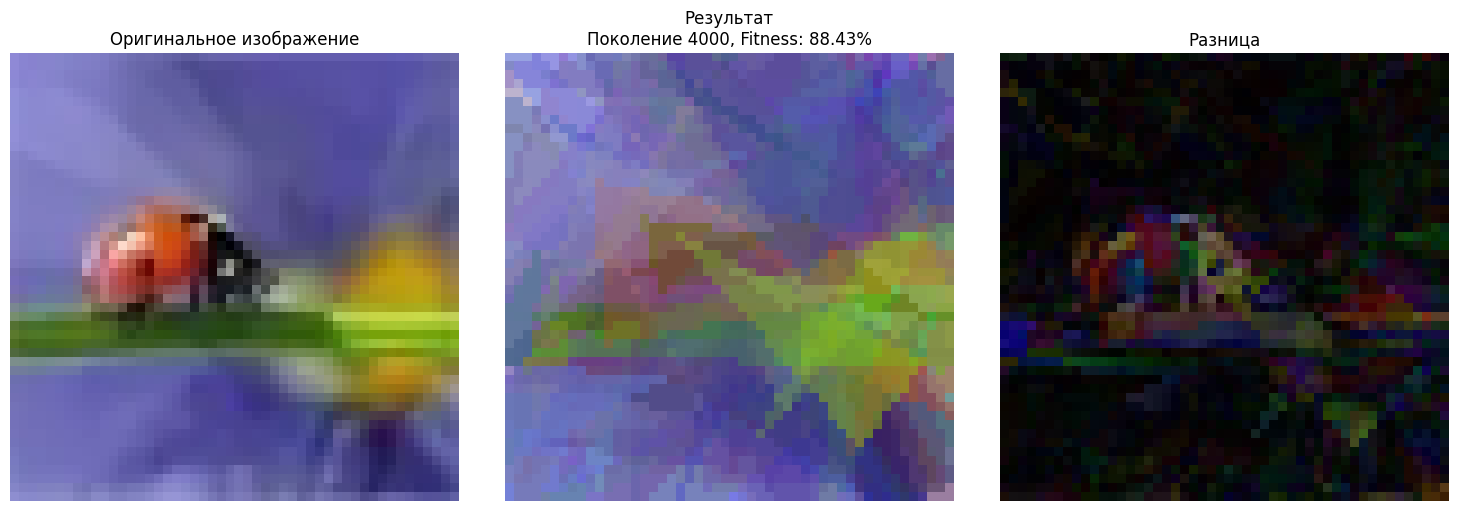

In [17]:
import matplotlib.pyplot as plt
from PIL import ImageChops

print("\nЛучший результат:", df["max_fitness"].max(), "%")

best_opt = df.loc[df["max_fitness"].idxmax()]
best_img = Image.open(best_opt["outpath"])

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(target)
plt.title("Оригинальное изображение")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(best_img)
plt.title(
    f'Результат\nПоколение {int(best_opt["generation"])}, '
    f'Fitness: {best_opt["max_fitness"]:.2f}%'
)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(ImageChops.difference(target, best_img))
plt.title("Разница")
plt.axis("off")

plt.tight_layout()
plt.show()